<a href="https://colab.research.google.com/github/revanangrh/Machine-Learning-/blob/main/ML_11_EnsembleLearning_RevanAnugerah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Import library yang dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score

print("Library berhasil di-import!")

Library berhasil di-import!


In [6]:
# Load Data menggunakan separator ';' sesuai format file Anda
df = pd.read_csv('Dataset_ginjal.csv', sep=';')
df.tail()

,Bp,Sg,Al,Su,Rbc,Bu,Sc,Sod,Pot,Hemo,Wbcc,Rbcc,Htn,Class
395,800,102,0,0,10,490,5,1500,49,157,67000,49,0,0
396,700,1025,0,0,10,310,12,1410,35,165,78000,62,0,0
397,800,102,0,0,10,260,6,1370,44,158,66000,54,0,0
398,600,1025,0,0,10,500,10,1350,49,142,72000,59,0,0
399,800,1025,0,0,10,180,11,1410,35,158,68000,61,0,0


In [7]:
# Memeriksa Tipe Data
df.info()

# Menghitung persentase duplikasi
percentage_duplicates = (df.duplicated().sum() / df.shape[0]) * 100
print("\nJumlah duplikasi : ", df.duplicated().sum())
print(f"Persentase duplikasi: {percentage_duplicates:.2f}%")

# Memeriksa Parameter Statistik
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Bp      400 non-null    int64
 1   Sg      400 non-null    int64
 2   Al      400 non-null    int64
 3   Su      400 non-null    int64
 4   Rbc     400 non-null    int64
 5   Bu      400 non-null    int64
 6   Sc      400 non-null    int64
 7   Sod     400 non-null    int64
 8   Pot     400 non-null    int64
 9   Hemo    400 non-null    int64
 10  Wbcc    400 non-null    int64
 11  Rbcc    400 non-null    int64
 12  Htn     400 non-null    int64
 13  Class   400 non-null    int64
dtypes: int64(14)
memory usage: 43.9 KB

Jumlah duplikasi :  0
Persentase duplikasi: 0.00%


,Bp,Sg,Al,Su,Rbc,Bu,Sc,Sod,Pot,Hemo,Wbcc,Rbcc,Htn,Class
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,764.550000,475.687500,10.150000,3.950000,8.825000,574.055000,43.197500,4067.440000,137.95250,271.870000,84060.900000,185.910000,3.860000,0.625000
std,134.765358,451.605135,12.723294,10.400381,3.224184,492.859705,80.428604,5113.592371,175.12904,380.706503,25232.199764,199.375194,5.363517,0.484729
min,500.000000,101.000000,0.000000,0.000000,0.000000,15.000000,4.000000,45.000000,25.00000,31.000000,22000.000000,21.000000,0.000000,0.000000
25%,700.000000,102.000000,0.000000,0.000000,10.000000,270.000000,9.000000,1350.000000,40.00000,108.750000,69750.000000,45.000000,0.000000,0.000000
50%,780.000000,102.000000,10.000000,0.000000,10.000000,440.000000,14.000000,1400.000000,47.00000,135.000000,84060.000000,54.000000,0.000000,1.000000
75%,800.000000,1015.000000,20.000000,0.000000,10.000000,617.500000,32.250000,1500.000000,58.25000,158.000000,94000.000000,471.000000,10.000000,1.000000
max,1800.000000,1025.000000,50.000000,50.000000,10.000000,3910.000000,760.000000,13753.000000,470.00000,1253.000000,264000.000000,471.000000,37.000000,1.000000


In [8]:
# Menghapus Data Duplikat jika ada
df.drop_duplicates(inplace=True)
print("Jumlah Duplikasi Setelah Dihapus: ", df.duplicated().sum())

Jumlah Duplikasi Setelah Dihapus:  0


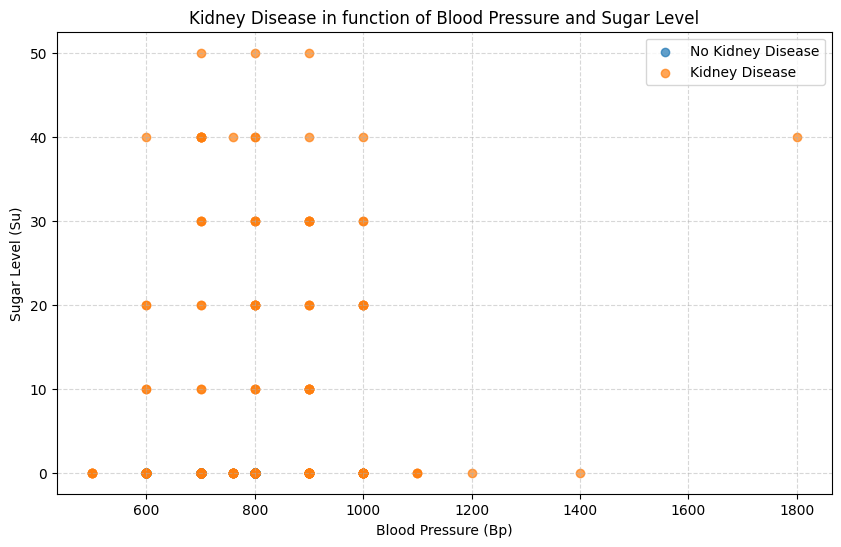

In [9]:
plt.figure(figsize=(10,6))

# Target = 0 (Normal / Tidak Sakit)
plt.scatter(x=df[df['Class']==0]['Bp'], y=df[df['Class']==0]['Su'], alpha=0.7)
# Target = 1 (Sakit Ginjal)
plt.scatter(x=df[df['Class']==1]['Bp'], y=df[df['Class']==1]['Su'], alpha=0.7)

plt.title("Kidney Disease in function of Blood Pressure and Sugar Level")
plt.xlabel("Blood Pressure (Bp)")
plt.ylabel("Sugar Level (Su)")
plt.legend(["No Kidney Disease", "Kidney Disease"])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

/tmp/ipykernel_4764/3094349874.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["Bp"], y=df["Sc"], errorbar=None, palette="muted")


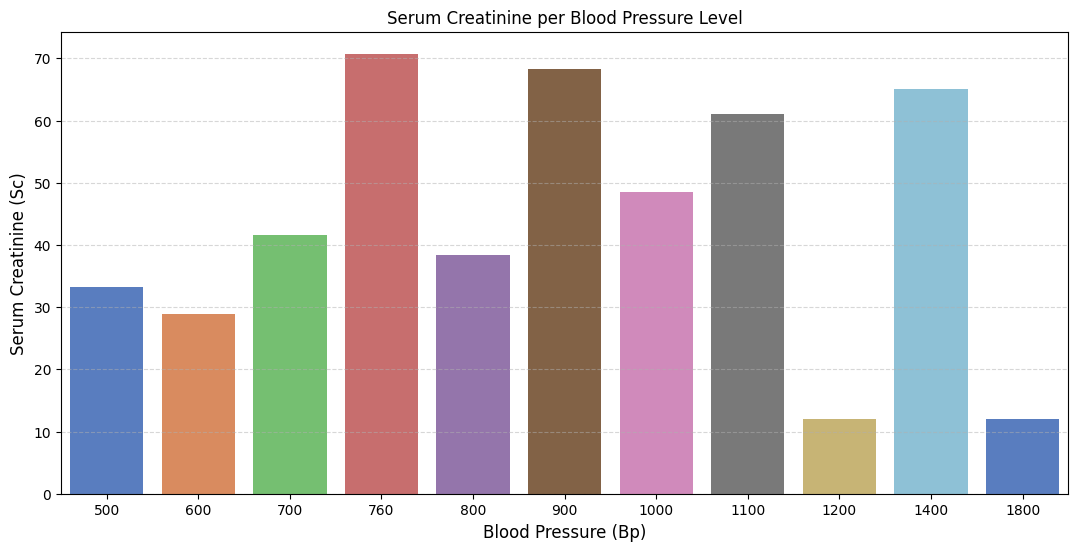

In [10]:
plt.figure(figsize=(13,6))
sns.barplot(x=df["Bp"], y=df["Sc"], errorbar=None, palette="muted")
plt.xlabel('Blood Pressure (Bp)', fontsize=12)
plt.ylabel('Serum Creatinine (Sc)', fontsize=12)
plt.title('Serum Creatinine per Blood Pressure Level')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [11]:
# Semua data di dataset ini sudah berupa angka (numerik), jadi langsung split fitur dan target
X = df.drop('Class', axis=1)
Y = df['Class']

# Standarisasi fitur agar skala data seragam
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

# Pisahkan data train dan test (75% latihan, 25% uji)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.25, random_state=3)
print(f"Data latihan: {X_train.shape[0]} baris, Data uji: {X_test.shape[0]} baris")

Data latihan: 300 baris, Data uji: 100 baris


In [12]:
# Inisialisasi model-modelnya
rf = RandomForestClassifier(random_state=3)
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=3)

# Fit model ke data latih
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

# Simpan model dalam sebuah list
models = [rf, gb]
Model_Names = ['RandomForestClassifier', 'XgBoost']

# Menghitung Akurasi
train_accuracy = []
test_accuracy = []

for i in range(len(models)):
    yhat = models[i].predict(X_test)
    yhat_t = models[i].predict(X_train)
    train_accuracy.append(accuracy_score(y_train, yhat_t))
    test_accuracy.append(accuracy_score(y_test, yhat))

# Menyimpan ke DataFrame Akurasi
Accuracy_score_df = pd.DataFrame({
    'Model': Model_Names,
    'Train_Accuracy': train_accuracy,
    'Test_Accuracy': test_accuracy
})

print("=== TABEL SKOR AKURASI MODEL ===")
Accuracy_score_df

=== TABEL SKOR AKURASI MODEL ===


,Model,Train_Accuracy,Test_Accuracy
0,RandomForestClassifier,1.0,0.98
1,XgBoost,1.0,0.97


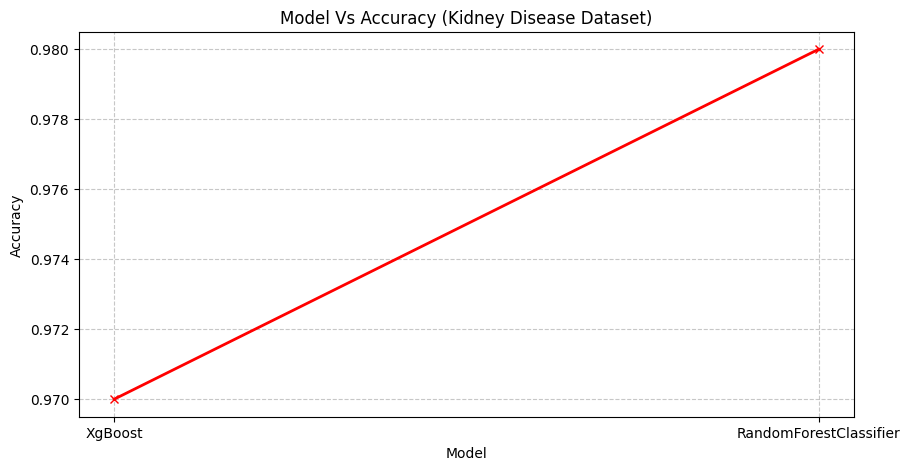

In [13]:
score = dict(zip(Model_Names, Accuracy_score_df['Test_Accuracy'].values))
score = {k: v for k, v in sorted(score.items(), key=lambda item: item[1])}

# Membuat Grafik Perbandingan Model dan Akurasi
plt.figure(figsize=(10,5))
plt.plot(list(score.keys()), list(score.values()), marker='x', color='red', linewidth=2)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Vs Accuracy (Kidney Disease Dataset)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [14]:
# Mencari model terbaik otomatis
best_model_info = Accuracy_score_df.loc[Accuracy_score_df['Test_Accuracy'].idxmax()]
print("Model terbaik berdasarkan akurasi pada data uji:")
print(best_model_info)

best_model_name = best_model_info['Model']
best_model_index = Model_Names.index(best_model_name)
best_model = models[best_model_index]

# Lakukan prediksi dan cetak Laporan Klasifikasi
y_pred = best_model.predict(X_test)
print("\n=== Laporan Klasifikasi untuk Model Terbaik ===")
print(classification_report(y_test, y_pred))

Model terbaik berdasarkan akurasi pada data uji:
Model             RandomForestClassifier
Train_Accuracy                       1.0
Test_Accuracy                       0.98
Name: 0, dtype: object

=== Laporan Klasifikasi untuk Model Terbaik ===
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        35
           1       0.98      0.98      0.98        65

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



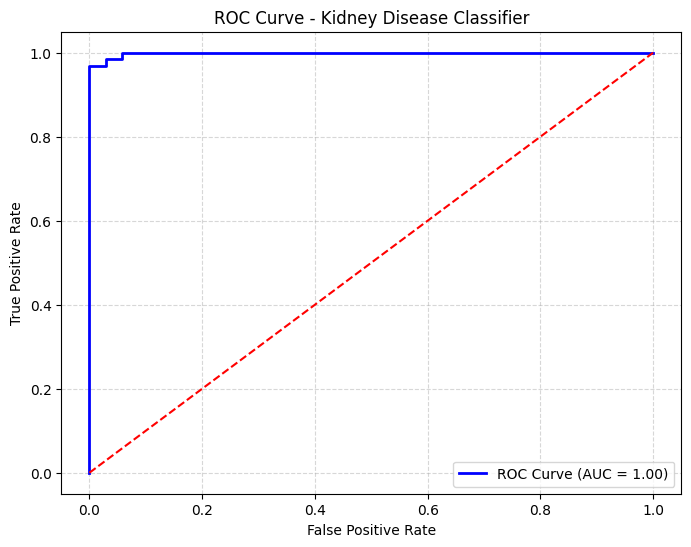

Area under the ROC curve (AUC): 1.00


In [15]:
# Mendapatkan nilai keputusan dari model terbaik
y_scores = best_model.predict_proba(X_test)[:, 1]

# Menghitung false positive rate, true positive rate, dan threshold
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Plotting ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_scores):.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Kidney Disease Classifier')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Hitung Area di Bawah Kurva ROC (AUC)
auc = roc_auc_score(y_test, y_scores)
print(f"Area under the ROC curve (AUC): {auc:.2f}")